<a href="https://colab.research.google.com/github/olifly/Lagadeildin/blob/main/DataVis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
SEASON_TO_ANALYSE = "S2"

In [8]:

base_url = f'https://raw.githubusercontent.com/olifly/Lagadeildin/main/data/{SEASON_TO_ANALYSE}/'
FILENAMES = ['competitors.csv', 'rounds.csv', 'submissions.csv', 'votes.csv']

file_urls = []
for filename in FILENAMES:
    full_url = base_url + filename
    file_urls.append(full_url)

In [9]:
dataframes = {}
DF_NAMES = ['competitors', 'rounds', 'submissions', 'votes']

for i, url in enumerate(file_urls):
    df_name = DF_NAMES[i]
    try:
        df = pd.read_csv(url)
        dataframes[df_name] = df
    except Exception as e:
        print(f"Error loading {url}: {e}")

In [15]:
import pandas as pd

# 1. Merge votes with submissions
votes_submissions = pd.merge(
    dataframes['votes'],
    dataframes['submissions'],
    on=['Spotify URI', 'Round ID'],
    how='inner'
)

# 2. Merge with competitors to get names
merged_data = pd.merge(
    votes_submissions,
    dataframes['competitors'],
    left_on='Submitter ID',
    right_on='ID',
    how='inner'
)

# 3. Group by Round, Submitter and Name to sum points
round_results = merged_data.groupby(['Round ID', 'Submitter ID', 'Name'])['Points Assigned'].sum().reset_index()

# 4. Identify the winner of each round (highest points)
round_winners = round_results.loc[round_results.groupby('Round ID')['Points Assigned'].idxmax()].copy()

# 5. Merge with rounds to get the Round Name
round_winners_with_names = pd.merge(
    round_winners,
    dataframes['rounds'][['ID', 'Name']],
    left_on='Round ID',
    right_on='ID',
    how='left',
    suffixes=('', '_round')
)

# 6. Display the results with Round Name
print('--- Round Winners ---')
display(round_winners_with_names[['Name_round', 'Name', 'Points Assigned']].rename(columns={'Name_round': 'Round Name', 'Name': 'Winner Name'}))

# Save for next steps
round_standings = round_results

--- Round Winners ---


,Round Name,Winner Name,Points Assigned
0,Ungir Sjálfstæðismenn,Eiríkur Stefán Ásgeirsson,45


In [12]:
import pandas as pd

# 1. Group by Name and Submitter ID to calculate total season points
season_leaderboard = round_standings.groupby(['Name', 'Submitter ID'])['Points Assigned'].sum().reset_index()

# 2. Sort by total points in descending order
season_leaderboard = season_leaderboard.sort_values(by='Points Assigned', ascending=False).reset_index(drop=True)

# 3. Rename column for clarity
season_leaderboard = season_leaderboard.rename(columns={'Points Assigned': 'Total Points'})

# 4. Identify the season leader
season_leader = season_leaderboard.iloc[0]

# 5. Display results
print('--- Season Leaderboard ---')
display(season_leaderboard)

print(f"\nTHE CURRENT SEASON LEADER IS: {season_leader['Name']} with {season_leader['Total Points']} points.")

--- Season Leaderboard ---


,Name,Submitter ID,Total Points
0,Eiríkur Stefán Ásgeirsson,6189c19985104f33a8791204c9cb0dd0,45
1,Ólafur Haukur Flygenring,1f0a3fccd8bc4fd488229256089548da,36
2,G-Unit,39e5af96218c47129dc5d1a8312dacf3,18
3,Grímur Gíslason,1c9f3ff117d247a1b84f06084cfb2aa0,18
4,Styrmir Kristjansson,9766f4be1e5d4ea4a8be9904dcc55984,17
5,Jónas Tryggvi Jóhannsson,8df4b7c784ab4da09f05cdafa0937247,10
6,Bjarni Ólafsson,aca0e792c50d4deeba9b8163723a08d3,6
7,Jóhann Ævar Grímsson,d9c193a018a84feaa47f8c064a5c3306,5
8,Stefán Kári Sveinbjörnsson,0ecd690cf4b845998168f409d7b2abee,3
9,Birgir Indriðason,86d2dce33769416bb6ed85729b0fef45,0



THE CURRENT SEASON LEADER IS: Eiríkur Stefán Ásgeirsson with 45 points.


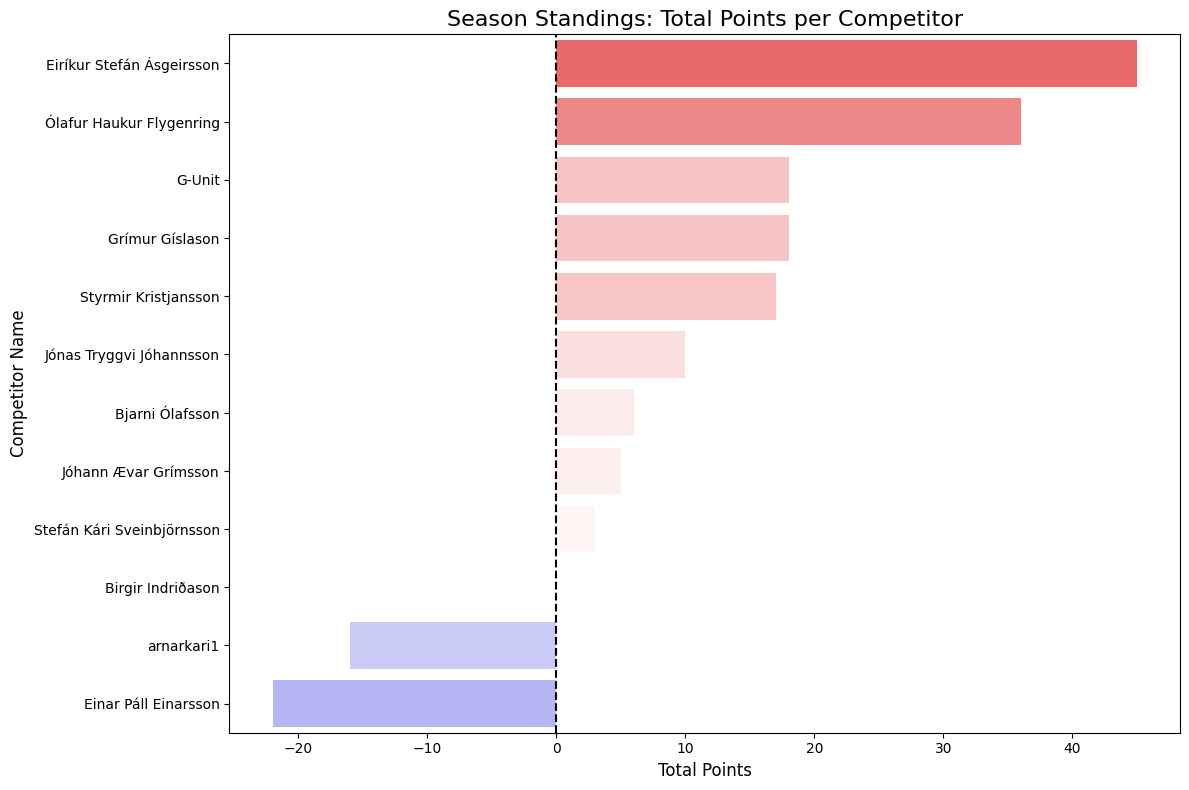

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import numpy as np

# 1. Prepare colors based on point values
# We adjust the vmin and vmax slightly beyond the actual data range
# This ensures that scores near zero aren't perfectly white
max_abs = max(season_leaderboard['Total Points'].abs().max(), 1)
# Use a slightly smaller range for normalization to increase saturation
color_limit = max_abs * 1.5
norm = mcolors.TwoSlopeNorm(vmin=-color_limit, vcenter=0, vmax=color_limit)
colors = [plt.cm.bwr(norm(val)) for val in season_leaderboard['Total Points']]

# 2. Create the plot
plt.figure(figsize=(12, 8))
ax = sns.barplot(
    data=season_leaderboard,
    x='Total Points',
    y='Name',
    palette=colors,
    hue='Name',
    legend=False
)

# 3. Add a vertical line at zero for clarity
plt.axvline(0, color='black', lw=1.5, ls='--')

# 4. Titles and labels
plt.title('Season Standings: Total Points per Competitor', fontsize=16)
plt.xlabel('Total Points', fontsize=12)
plt.ylabel('Competitor Name', fontsize=12)

plt.tight_layout()
plt.show()